In [8]:
import numpy as np 
import matplotlib.pyplot as plt

In [9]:
x=np.linspace(0,2*np.pi,1000)
print(x[:10])
print("Toplam veri sayısı:",len(x))

[0.         0.00628947 0.01257895 0.01886842 0.0251579  0.03144737
 0.03773685 0.04402632 0.0503158  0.05660527]
Toplam veri sayısı: 1000


In [10]:
y=np.sin(x)
print(y[:10])

[0.         0.00628943 0.01257862 0.0188673  0.02515525 0.03144219
 0.03772789 0.0440121  0.05029457 0.05657505]


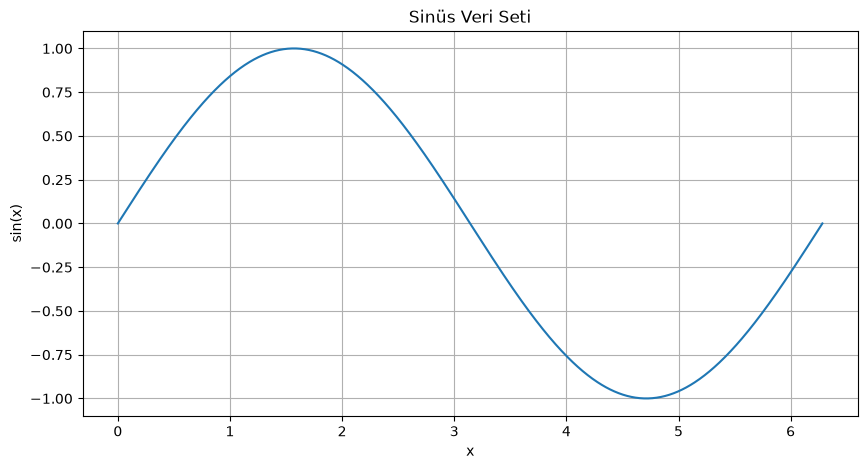

In [11]:
plt.figure(figsize=(10,5))
plt.plot(x,y)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Sinüs Veri Seti")
plt.grid()
plt.show()

In [12]:
for i in range(0,1000,100):
    print(f"x={x[i]:.3f} y={y[i]:.3f}")

x=0.000 y=0.000
x=0.629 y=0.588
x=1.258 y=0.951
x=1.887 y=0.950
x=2.516 y=0.586
x=3.145 y=-0.003
x=3.774 y=-0.591
x=4.403 y=-0.952
x=5.032 y=-0.949
x=5.661 y=-0.583


In [13]:
#verileri karıştırmak için indisler oluşturuyoruz
indices=np.arange(len(x))
#aynı sonucu tekrar üretebilmek için sabit random seed
np.random.seed(42)
#indisleri karıştır
np.random.shuffle(indices)

print(indices[:20])

[521 737 740 660 411 678 626 513 859 136 811  76 636 973 938 899 280 883
 761 319]


In [14]:
#verinin %80 eğitim için
train_size=int(0.8*len(x))

train_indices=indices[:train_size]
test_indices=indices[train_size:]

x_train=x[train_indices]
y_train=y[train_indices]

x_test=x[test_indices]
y_test=y[test_indices]

print("Eğitim verisi:",len(x_train))
print("Test verisi:",len(x_test))

                       

Eğitim verisi: 800
Test verisi: 200


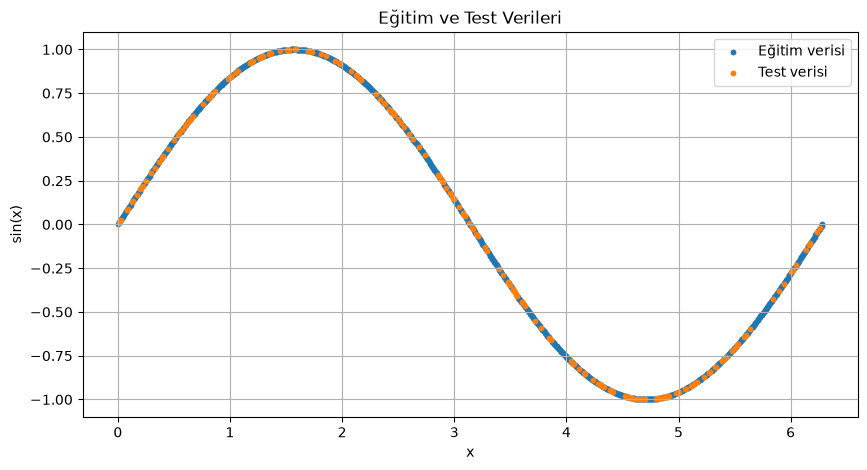

In [15]:
plt.figure(figsize=(10,5))

plt.scatter(x_train,y_train,label="Eğitim verisi",s=10)
plt.scatter(x_test,y_test,label="Test verisi",s=10)

plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title("Eğitim ve Test Verileri")
plt.legend()
plt.grid()
plt.show()

In [16]:
import tensorflow as tf

In [17]:
print(tf.__version__)

2.22.0-rc0


In [18]:
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(16,activation="relu"),
    tf.keras.layers.Dense(16,activation="relu"),
    tf.keras.layers.Dense(1)
])
    

In [19]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer="adam",
    loss="mse"
)

In [22]:
history=model.fit(
    x_train,
    y_train,
    epochs=100,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4050 - val_loss: 0.4007
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3616 - val_loss: 0.3627
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3224 - val_loss: 0.3239
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2871 - val_loss: 0.2912
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2560 - val_loss: 0.2625
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2292 - val_loss: 0.2374
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2067 - val_loss: 0.2171
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1887 - val_loss: 0.2010
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1751 - val_loss: 0.1890
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1651 - val_loss: 0.1807
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1581 - val_loss: 0.1749
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1

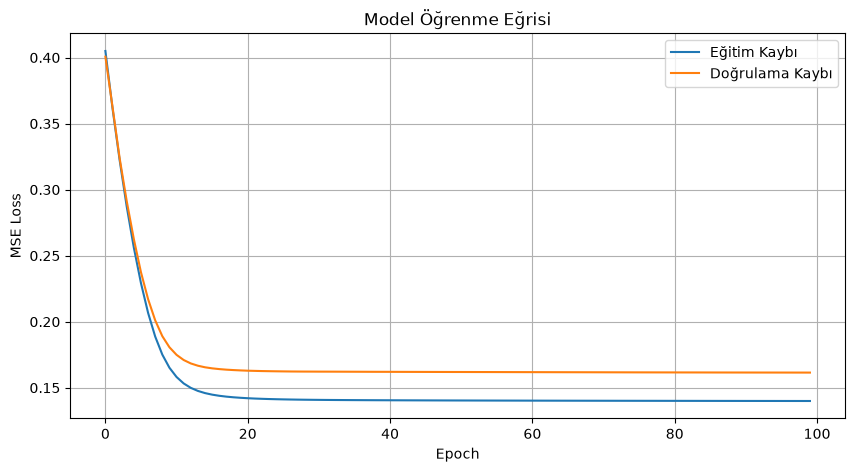

In [24]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"],label="Eğitim Kaybı")
plt.plot(history.history["val_loss"],label="Doğrulama Kaybı")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Model Öğrenme Eğrisi")

plt.legend()
plt.grid()

plt.show()

In [25]:
y_pred=model.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


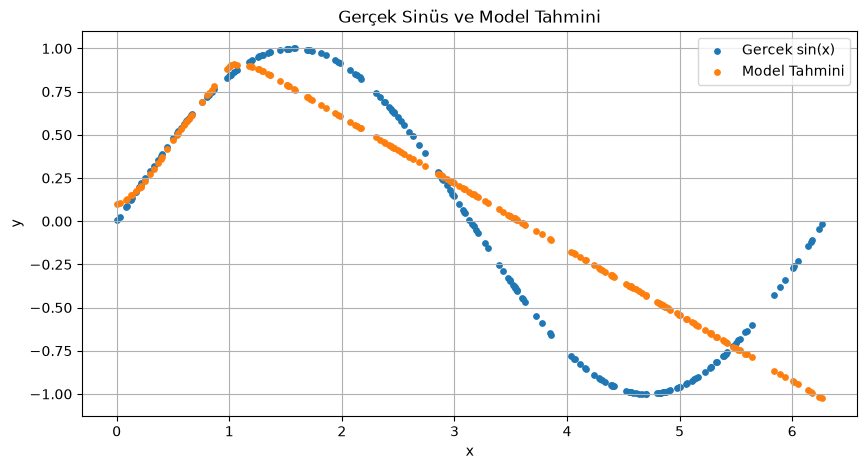

In [26]:
plt.figure(figsize=(10,5))

plt.scatter(x_test,y_test,label="Gercek sin(x)",s=15)
plt.scatter(x_test,y_pred,label="Model Tahmini",s=15)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Gerçek Sinüs ve Model Tahmini")

plt.legend()
plt.grid()
plt.show()

In [27]:
model2=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(16,activation="tanh"),
    tf.keras.layers.Dense(16,activation="tanh"),
    tf.keras.layers.Dense(1)
])
    

In [28]:
model2.compile(
    optimizer="adam",
    loss="mse"
)

In [29]:
history2=model2.fit(
    x_train,
    y_train,
    epochs=200,
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5901 - val_loss: 0.5665
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4691 - val_loss: 0.4683
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3805 - val_loss: 0.3784
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3088 - val_loss: 0.3025
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2514 - val_loss: 0.2407
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2111 - val_loss: 0.1971
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1876 - val_loss: 0.1719
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1751 - val_loss: 0.1589
Epoch 9/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1668 - val_loss: 0.1518
Epoch 10/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1595 - val_loss: 0.1467
Epoch 11/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1525 - val_loss: 0.1422
Epoch 12/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1

In [30]:
y_pred2=model2.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


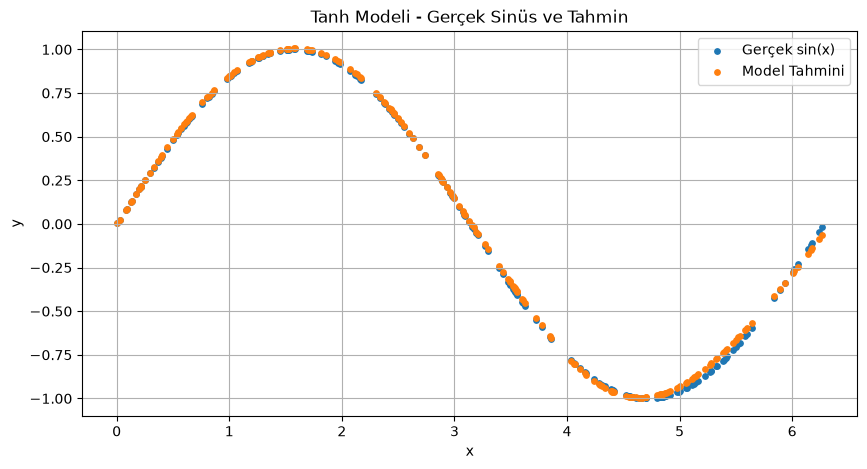

In [31]:
plt.figure(figsize=(10, 5))

plt.scatter(x_test, y_test, label="Gerçek sin(x)", s=15)
plt.scatter(x_test, y_pred2, label="Model Tahmini", s=15)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Tanh Modeli - Gerçek Sinüs ve Tahmin")

plt.legend()
plt.grid()

plt.show()

In [34]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

mse_relu=mean_squared_error(y_test,y_pred)
mae_relu=mean_absolute_error(y_test,y_pred)

mse_tanh=mean_squared_error(y_test,y_pred2)
mae_tanh=mean_absolute_error(y_test,y_pred2)

print("RELU MODELI")
print("MSE",mse_relu)
print("MAE",mae_relu)

print("\nTanh MODELI")
print("MSE",mse_tanh)
print("MAE",mae_tanh)

RELU MODELI
MSE 0.13406876271151366
MAE 0.2787390513056144

Tanh MODELI
MSE 0.00028316331154032675
MAE 0.011745518509001913


In [35]:
for i in range(10):
    print(
        f"x={x_test[i]:.3f}-"
        f"gerçek={y_test[i]:.3f}-"
        f"tahmin={y_pred2[i][0]:.3f}"
    )

x=3.497-gerçek=-0.348-tahmin=-0.333
x=6.019-gerçek=-0.261-tahmin=-0.270
x=3.629-gerçek=-0.468-tahmin=-0.455
x=5.000-gerçek=-0.959-tahmin=-0.930
x=0.535-gerçek=0.510-tahmin=0.517
x=1.522-gerçek=0.999-tahmin=1.004
x=4.390-gerçek=-0.948-tahmin=-0.957
x=1.000-gerçek=0.841-tahmin=0.846
x=3.296-gerçek=-0.153-tahmin=-0.142
x=0.220-gerçek=0.218-tahmin=0.220


In [36]:
converter=tf.lite.TFLiteConverter.from_keras_model(model2)
tflite_model=converter.convert()

INFO:tensorflow:Assets written to: C:\Users\Ercan\AppData\Local\Temp\tmp55m82_4a\assets


INFO:tensorflow:Assets written to: C:\Users\Ercan\AppData\Local\Temp\tmp55m82_4a\assets


Saved artifact at 'C:\Users\Ercan\AppData\Local\Temp\tmp55m82_4a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2151115390512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2151165880720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2151165872800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2151165872320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2151165871840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2151169719616: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [37]:
model2

<Sequential name=sequential_2, built=True>

In [38]:
with open("sine_model.tflite","wb") as f:
    f.write(tflite_model)

In [39]:
import os

model_size=os.path.getsize("sine_model.tflite")

print("TFLite model boyutu:",model_size,"byte")
print("TFLite model boyutu:",model_size/1024,"Kbyte")

TFLite model boyutu: 3440 byte
TFLite model boyutu: 3.359375 Kbyte


In [40]:
def representative_dataset():
    for value in x_train[:200]:
        yield[np.array([[value]],dtype=np.float32)]

In [43]:
converter=tf.lite.TFLiteConverter.from_keras_model(model2)

converter.optimizations=[tf.lite.Optimize.DEFAULT]
converter.representative_dataset=representative_dataset

converter.target_spec.supported_ops=[
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type=tf.int8
converter.inference_output_type=tf.int8

tflite_int8_model=converter.convert()


INFO:tensorflow:Assets written to: C:\Users\Ercan\AppData\Local\Temp\tmpg1fmsx87\assets


INFO:tensorflow:Assets written to: C:\Users\Ercan\AppData\Local\Temp\tmpg1fmsx87\assets


Saved artifact at 'C:\Users\Ercan\AppData\Local\Temp\tmpg1fmsx87'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_8')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2151115390512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2151165880720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2151165872800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2151165872320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2151165871840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2151169719616: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\Ercan\anaconda3\Lib\site-packages\tensorflow\lite\python\convert.py:960: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [44]:
with open("sine_model_int8.tflite","wb") as f:
    f.write(tflite_int8_model)
    

In [45]:
int8_size=os.path.getsize("sine_model_int8.tflite")

print("Float TFLite:",model_size,"byte")
print("INT8 TFLite :",int8_size,"byte")
print("INT8 TFLite :",int8_size/1024,"Kbyte")

Float TFLite: 3440 byte
INT8 TFLite : 3720 byte
INT8 TFLite : 3.6328125 Kbyte


In [46]:
interpreter = tf.lite.Interpreter(
    model_path="sine_model_int8.tflite"
)

interpreter.allocate_tensors()

C:\Users\Ercan\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:468: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [47]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("INPUT:")
print(input_details)

print("\nOUTPUT:")
print(output_details)

INPUT:
[{'name': 'serving_default_keras_tensor_8:0', 'index': 0, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.024615278467535973, -128), 'quantization_parameters': {'scales': array([0.02461528], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]

OUTPUT:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 11, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.007845114916563034, -1), 'quantization_parameters': {'scales': array([0.00784511], dtype=float32), 'zero_points': array([-1], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


In [48]:
x_value = 1.0

input_scale, input_zero_point = input_details[0]["quantization"]

x_quantized = round(x_value / input_scale + input_zero_point)

print("Float giriş:", x_value)
print("Quantized giriş:", x_quantized)

Float giriş: 1.0
Quantized giriş: -87


In [49]:
input_data = np.array([[x_quantized]], dtype=np.int8)

interpreter.set_tensor(
    input_details[0]["index"],
    input_data
)

interpreter.invoke()

In [50]:
output_data = interpreter.get_tensor(
    output_details[0]["index"]
)

print("Ham INT8 çıktı:", output_data)

Ham INT8 çıktı: [[118]]


In [51]:
output_scale, output_zero_point = output_details[0]["quantization"]

y_quantized = output_data[0][0]

y_dequantized = (
    y_quantized - output_zero_point
) * output_scale

print("Dequantized tahmin:", y_dequantized)
print("Gerçek sin(1.0):", np.sin(1.0))

Dequantized tahmin: 0.933568675071001
Gerçek sin(1.0): 0.8414709848078965


In [52]:
int8_predictions = []

input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

for value in x_test:

    # Float giriş → INT8
    x_q = round(value / input_scale + input_zero_point)

    # INT8 sınırlarının dışına çıkmasını engelle
    x_q = np.clip(x_q, -128, 127)

    input_data = np.array([[x_q]], dtype=np.int8)

    # Modele ver
    interpreter.set_tensor(
        input_details[0]["index"],
        input_data
    )

    interpreter.invoke()

    # INT8 çıktı
    output_data = interpreter.get_tensor(
        output_details[0]["index"]
    )

    y_q = output_data[0][0]

    # INT8 → Float
    y_float = (y_q - output_zero_point) * output_scale

    int8_predictions.append(y_float)

C:\Users\Ercan\AppData\Local\Temp\ipykernel_5716\940363012.py:32: RuntimeWarning: overflow encountered in scalar subtract
  y_float = (y_q - output_zero_point) * output_scale


In [53]:
int8_predictions = np.array(int8_predictions)

In [54]:
mse_int8 = mean_squared_error(
    y_test,
    int8_predictions
)

mae_int8 = mean_absolute_error(
    y_test,
    int8_predictions
)

print("FLOAT MODEL")
print("MSE:", mse_tanh)
print("MAE:", mae_tanh)

print("\nINT8 MODEL")
print("MSE:", mse_int8)
print("MAE:", mae_int8)

FLOAT MODEL
MSE: 0.00028316331154032675
MAE: 0.011745518509001913

INT8 MODEL
MSE: 0.1588273116548254
MAE: 0.1119136607217741


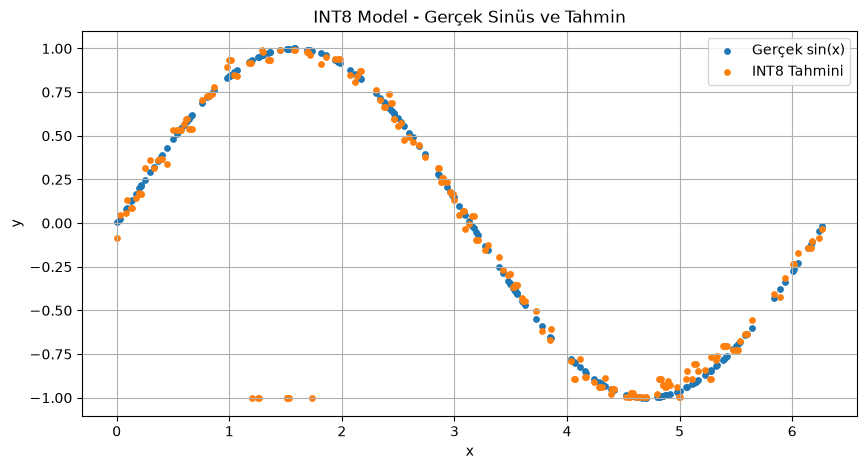

In [55]:
plt.figure(figsize=(10, 5))

plt.scatter(
    x_test,
    y_test,
    label="Gerçek sin(x)",
    s=15
)

plt.scatter(
    x_test,
    int8_predictions,
    label="INT8 Tahmini",
    s=15
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("INT8 Model - Gerçek Sinüs ve Tahmin")

plt.legend()
plt.grid()

plt.show()

In [56]:
for i, value in enumerate(x_test):

    if int8_predictions[i] < -0.9 and y_test[i] > 0.5:
        print(
            f"x={value:.4f} | "
            f"gercek={y_test[i]:.4f} | "
            f"INT8={int8_predictions[i]:.4f}"
        )

x=1.5221 | gercek=0.9988 | INT8=-1.0042
x=1.5095 | gercek=0.9981 | INT8=-1.0042
x=1.2579 | gercek=0.9514 | INT8=-1.0042
x=1.2642 | gercek=0.9534 | INT8=-1.0042
x=1.5158 | gercek=0.9985 | INT8=-1.0042
x=1.5283 | gercek=0.9991 | INT8=-1.0042
x=1.7359 | gercek=0.9864 | INT8=-1.0042
x=1.2013 | gercek=0.9325 | INT8=-1.0042


In [59]:
test_value = 1.5221

x_q = round(test_value / input_scale + input_zero_point)
x_q = np.clip(x_q, -128, 127)

input_data = np.array([[x_q]], dtype=np.int8)

interpreter.set_tensor(
    input_details[0]["index"],
    input_data
)

interpreter.invoke()

output_data = interpreter.get_tensor(
    output_details[0]["index"]
)

y_q = int(output_data[0][0])

y_float = (
    y_q - int(output_zero_point)
) * output_scale

print("x float       :", test_value)
print("x INT8        :", x_q)
print("Ham y INT8    :", y_q)
print("Dequantized y :", y_float)
print("Gerçek sin(x) :", np.sin(test_value))

x float       : 1.5221
x INT8        : -66
Ham y INT8    : 127
Dequantized y : 1.0041747093200684
Gerçek sin(x) : 0.998814568160515


In [60]:
int8_predictions = []

input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

for value in x_test:

    # Float giriş -> INT8
    x_q = round(value / input_scale + input_zero_point)
    x_q = np.clip(x_q, -128, 127)

    input_data = np.array([[x_q]], dtype=np.int8)

    interpreter.set_tensor(
        input_details[0]["index"],
        input_data
    )

    interpreter.invoke()

    output_data = interpreter.get_tensor(
        output_details[0]["index"]
    )

    # KRİTİK: numpy.int8 -> normal Python int
    y_q = int(output_data[0][0])

    # INT8 -> Float
    y_float = (
        y_q - int(output_zero_point)
    ) * output_scale

    int8_predictions.append(y_float)

int8_predictions = np.array(int8_predictions)

In [61]:
mse_int8 = mean_squared_error(y_test, int8_predictions)
mae_int8 = mean_absolute_error(y_test, int8_predictions)

print("FLOAT MODEL")
print("MSE:", mse_tanh)
print("MAE:", mae_tanh)

print("\nINT8 MODEL")
print("MSE:", mse_int8)
print("MAE:", mae_int8)

FLOAT MODEL
MSE: 0.00028316331154032675
MAE: 0.011745518509001913

INT8 MODEL
MSE: 0.0018099026562873447
MAE: 0.03373134466600762


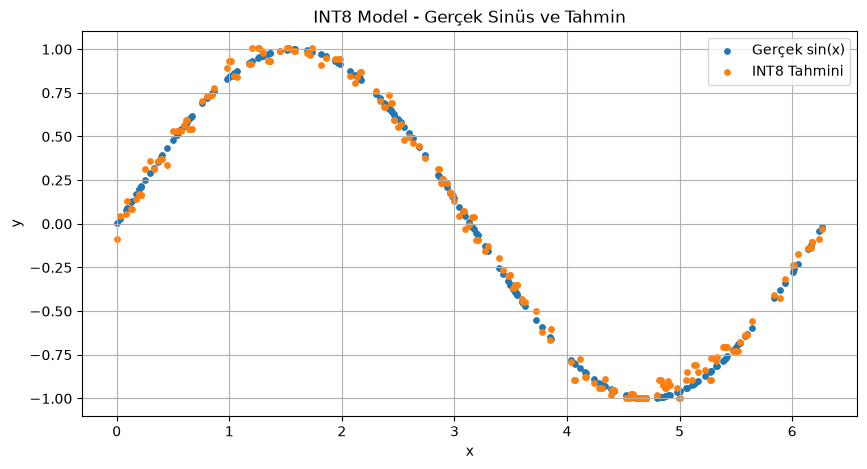

In [62]:
plt.figure(figsize=(10, 5))

plt.scatter(x_test, y_test, label="Gerçek sin(x)", s=15)
plt.scatter(x_test, int8_predictions, label="INT8 Tahmini", s=15)

plt.xlabel("x")
plt.ylabel("y")
plt.title("INT8 Model - Gerçek Sinüs ve Tahmin")

plt.legend()
plt.grid()

plt.show()

In [63]:
mse_int8 = mean_squared_error(y_test, int8_predictions)
mae_int8 = mean_absolute_error(y_test, int8_predictions)

print("FLOAT MODEL")
print("MSE:", mse_tanh)
print("MAE:", mae_tanh)

print("\nINT8 MODEL")
print("MSE:", mse_int8)
print("MAE:", mae_int8)

FLOAT MODEL
MSE: 0.00028316331154032675
MAE: 0.011745518509001913

INT8 MODEL
MSE: 0.0018099026562873447
MAE: 0.03373134466600762


In [64]:
with open("sine_model_int8.tflite", "rb") as f:
    model_data = f.read()

with open("sine_model_data.h", "w") as f:
    f.write("const unsigned char sine_model_data[] = {\n")

    for i, byte in enumerate(model_data):
        f.write(f"0x{byte:02x}, ")

        if (i + 1) % 12 == 0:
            f.write("\n")

    f.write("\n};\n")
    f.write(f"const unsigned int sine_model_data_len = {len(model_data)};\n")

In [1]:
with open("sine_model.tflite", "rb") as f:
    model_data = f.read()

with open("sine_model_float_data.h", "w") as f:
    f.write("const unsigned char sine_model_float_data[] = {\n")

    for i, byte in enumerate(model_data):
        f.write(f"0x{byte:02x}, ")

        if (i + 1) % 12 == 0:
            f.write("\n")

    f.write("\n};\n")
    f.write(
        f"const unsigned int sine_model_float_data_len = {len(model_data)};\n"
    )